<a href="https://colab.research.google.com/github/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri/blob/main/notebooks/03_multi_slice_reliability_check.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri.git
%cd /content/reliability-aware-ssdu-mri

Cloning into 'reliability-aware-ssdu-mri'...
remote: Enumerating objects: 363, done.
remote: Counting objects: 100% (221/221), done.
remote: Compressing objects: 100% (204/204), done.
remote: Total 363 (delta 130), reused 16 (delta 16), pack-reused 142 (from 1)
Receiving objects: 100% (363/363), 3.62 MiB | 13.59 MiB/s, done.
Resolving deltas: 100% (191/191), done.
/content/reliability-aware-ssdu-mri


In [3]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


In [4]:
import sys
sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import pandas as pd

from fastmri_data import load_fastmri_file, get_kspace_slice
from ssdu import split_acquired_mask
from models.dropout_cnn import DropoutCNNReconstructor
from training import prepare_single_coil_ssdu_input, total_ssdu_training_loss
from reliability import (
    stochastic_reconstructions,
    compute_mean_and_uncertainty,
    backproject_lambda_residual,
    normalize_map,
    map_alignment,
)

print("Notebook 03 setup complete.")

Notebook 03 setup complete.


#**Load data and define slice list**

In [5]:
file_path = "/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_6002495.h5"

data = load_fastmri_file(file_path)

kspace = data["kspace"]
mask = data["mask"]

print("K-space shape:", kspace.shape)
print("Mask shape:", mask.shape)
print("Acquisition:", data["attrs"].get("acquisition"))
print("Acceleration:", data["attrs"].get("acceleration"))

K-space shape: (16, 16, 768, 396)
Mask shape: (396,)
Acquisition: AXT2
Acceleration: 4


**define the slices:**

In [ ]:
slice_indices = [4, 8, 12]
coil_index = 0

print("Slices to test:", slice_indices)
print("Selected coil:", coil_index)

Slices to test: [4, 8, 12]
Selected coil: 0


#**Define one-slice reliability experiment function**

In [ ]:
def run_single_slice_reliability_experiment(
    kspace,
    mask,
    slice_index,
    coil_index=0,
    rho=0.4,
    split_seed=42,
    model_seed=0,
    num_steps=50,
    num_samples=8,
    features=16,
    dropout_p=0.1,
    lr=1e-4,
    lambda_img=1e7,
):
    """
    Train a dropout SSDU model on one single-coil slice and compute
    uncertainty-residual alignment.

    split_seed controls the Theta/Lambda SSDU split.
    model_seed controls CNN initialization and dropout randomness.
    """

    np.random.seed(model_seed)
    torch.manual_seed(model_seed)

    # Select one coil from one slice
    kspace_slice = kspace[slice_index]
    kspace_single = kspace_slice[coil_index]

    # SSDU split controlled only by split_seed
    theta_mask, lambda_mask = split_acquired_mask(
        mask=mask,
        rho=rho,
        seed=split_seed
    )

    # Prepare Theta-only input
    x_input, kspace_theta = prepare_single_coil_ssdu_input(
        kspace_single=kspace_single,
        theta_mask=theta_mask,
        normalize=True
    )

    # Model controlled by model_seed
    model = DropoutCNNReconstructor(
        in_channels=1,
        out_channels=1,
        features=features,
        dropout_p=dropout_p
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    ssdu_history = []
    img_history = []

    model.train()

    for step in range(num_steps):
        optimizer.zero_grad()

        x_pred = model(x_input)

        total_loss, ssdu_loss, img_loss = total_ssdu_training_loss(
            x_pred_tensor=x_pred,
            x_input_tensor=x_input,
            kspace_single=kspace_single,
            lambda_mask=lambda_mask,
            lambda_img=lambda_img,
        )

        total_loss.backward()
        optimizer.step()

        loss_history.append(total_loss.item())
        ssdu_history.append(ssdu_loss.item())
        img_history.append(img_loss.item())

    # Stochastic inference
    stochastic_outputs = stochastic_reconstructions(
        model=model,
        x_input_tensor=x_input,
        num_samples=num_samples
    )

    mean_image, uncertainty_map = compute_mean_and_uncertainty(
        stochastic_outputs
    )

    residual_energy = backproject_lambda_residual(
        mean_image=mean_image,
        measured_kspace=kspace_single,
        lambda_mask=lambda_mask
    )

    alignment = map_alignment(
        uncertainty_map,
        residual_energy
    )

    result = {
        "slice_index": slice_index,
        "coil_index": coil_index,
        "split_seed": split_seed,
        "model_seed": model_seed,
        "initial_ssdu_loss": ssdu_history[0],
        "final_ssdu_loss": ssdu_history[-1],
        "ssdu_reduction_percent": 100 * (ssdu_history[0] - ssdu_history[-1]) / ssdu_history[0],
        "initial_image_loss": img_history[0],
        "final_image_loss": img_history[-1],
        "alignment": alignment,
        "loss_history": loss_history,
        "ssdu_history": ssdu_history,
        "img_history": img_history,
        "mean_image": mean_image,
        "uncertainty_map": uncertainty_map,
        "residual_energy": residual_energy,
        "x_input": x_input.detach().cpu().numpy()[0, 0],
    }

    return result

In [ ]:
model_seed_list = [0, 1, 2, 3, 4]

fixed_split_results = []

for model_seed in model_seed_list:
    print(f"\nRunning model seed {model_seed} with fixed SSDU split...")

    result = run_single_slice_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=8,
        coil_index=0,
        rho=0.4,
        split_seed=42,
        model_seed=model_seed,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    fixed_split_results.append({
        "model_seed": model_seed,
        "initial_ssdu_loss": result["initial_ssdu_loss"],
        "final_ssdu_loss": result["final_ssdu_loss"],
        "ssdu_reduction_percent": result["ssdu_reduction_percent"],
        "alignment": result["alignment"],
    })

fixed_split_df = pd.DataFrame(fixed_split_results)
fixed_split_df


Running model seed 0 with fixed SSDU split...

Running model seed 1 with fixed SSDU split...

Running model seed 2 with fixed SSDU split...

Running model seed 3 with fixed SSDU split...

Running model seed 4 with fixed SSDU split...


,model_seed,initial_ssdu_loss,final_ssdu_loss,ssdu_reduction_percent,alignment
0,0,10912285.0,9636117.00,11.694783,0.661151
1,1,11113994.0,10719709.00,3.547645,0.600593
2,2,11180112.0,9586817.00,14.251154,0.156127
3,3,10317614.0,7328033.00,28.975507,0.658879
4,4,9736413.0,4039148.25,58.515028,0.695537


In [ ]:
print(fixed_split_df)

print("\nMean SSDU reduction %:", fixed_split_df["ssdu_reduction_percent"].mean())
print("Std SSDU reduction %:", fixed_split_df["ssdu_reduction_percent"].std())

print("\nMean alignment:", fixed_split_df["alignment"].mean())
print("Std alignment:", fixed_split_df["alignment"].std())
print("Min alignment:", fixed_split_df["alignment"].min())
print("Max alignment:", fixed_split_df["alignment"].max())

   model_seed  initial_ssdu_loss  final_ssdu_loss  ssdu_reduction_percent  \
0           0         10912285.0       9636117.00               11.694783   
1           1         11113994.0      10719709.00                3.547645   
2           2         11180112.0       9586817.00               14.251154   
3           3         10317614.0       7328033.00               28.975507   
4           4          9736413.0       4039148.25               58.515028   

   alignment  
0   0.661151  
1   0.600593  
2   0.156127  
3   0.658879  
4   0.695537  

Mean SSDU reduction %: 23.39682322618713
Std SSDU reduction %: 21.67360667450733

Mean alignment: 0.554457406674583
Std alignment: 0.22526995443788383
Min alignment: 0.1561271641333343
Max alignment: 0.6955366291711785


**test fixed model seed with different SSDU splits**

In [ ]:
split_seed_list = [0, 1, 2, 3, 4]

fixed_model_results = []

for split_seed in split_seed_list:
    print(f"\nRunning split seed {split_seed} with fixed model seed...")

    result = run_single_slice_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=8,
        coil_index=0,
        rho=0.4,
        split_seed=split_seed,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    fixed_model_results.append({
        "split_seed": split_seed,
        "initial_ssdu_loss": result["initial_ssdu_loss"],
        "final_ssdu_loss": result["final_ssdu_loss"],
        "ssdu_reduction_percent": result["ssdu_reduction_percent"],
        "alignment": result["alignment"],
    })

fixed_model_df = pd.DataFrame(fixed_model_results)
fixed_model_df


Running split seed 0 with fixed model seed...

Running split seed 1 with fixed model seed...

Running split seed 2 with fixed model seed...

Running split seed 3 with fixed model seed...

Running split seed 4 with fixed model seed...


,split_seed,initial_ssdu_loss,final_ssdu_loss,ssdu_reduction_percent,alignment
0,0,10138312.0,9039799.0,10.835265,0.734704
1,1,22203380.0,19738796.0,11.100040,0.782305
2,2,34829616.0,21775648.0,37.479506,0.668087
3,3,6563271.5,5961636.0,9.166701,0.528136
4,4,8400630.0,7493101.5,10.803100,0.654425


In [ ]:
print(fixed_model_df)

print("\nMean SSDU reduction %:", fixed_model_df["ssdu_reduction_percent"].mean())
print("Std SSDU reduction %:", fixed_model_df["ssdu_reduction_percent"].std())

print("\nMean alignment:", fixed_model_df["alignment"].mean())
print("Std alignment:", fixed_model_df["alignment"].std())
print("Min alignment:", fixed_model_df["alignment"].min())
print("Max alignment:", fixed_model_df["alignment"].max())

   split_seed  initial_ssdu_loss  final_ssdu_loss  ssdu_reduction_percent  \
0           0         10138312.0        9039799.0               10.835265   
1           1         22203380.0       19738796.0               11.100040   
2           2         34829616.0       21775648.0               37.479506   
3           3          6563271.5        5961636.0                9.166701   
4           4          8400630.0        7493101.5               10.803100   

   alignment  
0   0.734704  
1   0.782305  
2   0.668087  
3   0.528136  
4   0.654425  

Mean SSDU reduction %: 15.876922564788412
Std SSDU reduction %: 12.100405627035267

Mean alignment: 0.6735311930940127
Std alignment: 0.09631741303022967
Min alignment: 0.5281360866944695
Max alignment: 0.7823045939719063


**Stability test with longer training**

In [ ]:
long_train_result = run_single_slice_reliability_experiment(
    kspace=kspace,
    mask=mask,
    slice_index=8,
    coil_index=0,
    rho=0.4,
    split_seed=42,
    model_seed=0,
    num_steps=100,
    num_samples=8,
    features=16,
    dropout_p=0.1,
    lr=5e-5,
    lambda_img=1e7,
)

print("Slice:", long_train_result["slice_index"])
print("Initial SSDU loss:", long_train_result["initial_ssdu_loss"])
print("Final SSDU loss:", long_train_result["final_ssdu_loss"])
print("SSDU reduction %:", long_train_result["ssdu_reduction_percent"])
print("Initial image loss:", long_train_result["initial_image_loss"])
print("Final image loss:", long_train_result["final_image_loss"])
print("Uncertainty-residual alignment:", long_train_result["alignment"])

Slice: 8
Initial SSDU loss: 10912285.0
Final SSDU loss: 9808881.0
SSDU reduction %: 10.111576081453151
Initial image loss: 0.00573623226955533
Final image loss: 0.010856649838387966
Uncertainty-residual alignment: 0.6090550530232681


**Multi-slice reliability test**

In [ ]:
multi_slice_results = []

for slice_index in [4, 8, 12]:
    print(f"\nRunning slice {slice_index}...")

    result = run_single_slice_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        rho=0.4,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    multi_slice_results.append({
        "slice_index": slice_index,
        "initial_ssdu_loss": result["initial_ssdu_loss"],
        "final_ssdu_loss": result["final_ssdu_loss"],
        "ssdu_reduction_percent": result["ssdu_reduction_percent"],
        "alignment": result["alignment"],
    })

multi_slice_df = pd.DataFrame(multi_slice_results)
multi_slice_df


Running slice 4...

Running slice 8...

Running slice 12...


,slice_index,initial_ssdu_loss,final_ssdu_loss,ssdu_reduction_percent,alignment
0,4,23658390.0,20539922.0,13.181235,0.613072
1,8,10912285.0,9636117.0,11.694783,0.661151
2,12,17030082.0,14746922.0,13.406630,0.751131


In [ ]:
print(multi_slice_df)

print("\nMean SSDU reduction %:", multi_slice_df["ssdu_reduction_percent"].mean())
print("Std SSDU reduction %:", multi_slice_df["ssdu_reduction_percent"].std())

print("\nMean alignment:", multi_slice_df["alignment"].mean())
print("Std alignment:", multi_slice_df["alignment"].std())
print("Min alignment:", multi_slice_df["alignment"].min())
print("Max alignment:", multi_slice_df["alignment"].max())

   slice_index  initial_ssdu_loss  final_ssdu_loss  ssdu_reduction_percent  \
0            4         23658390.0       20539922.0               13.181235   
1            8         10912285.0        9636117.0               11.694783   
2           12         17030082.0       14746922.0               13.406630   

   alignment  
0   0.613072  
1   0.661151  
2   0.751131  

Mean SSDU reduction %: 12.760882373032317
Std SSDU reduction %: 0.9301222056918232

Mean alignment: 0.6751181319442235
Std alignment: 0.07008116422025672
Min alignment: 0.6130721760060471
Max alignment: 0.7511310431457027


#**Test four-way SSDU split**

In [6]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


**import the new function:**

In [7]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import ssdu
importlib.reload(ssdu)

from ssdu import split_acquired_mask_four_way

print("Four-way SSDU split imported successfully.")

Four-way SSDU split imported successfully.


**test it on the same fastMRI mask:**

In [8]:
theta_mask, lambda_train_mask, lambda_cal_mask, lambda_eval_mask = split_acquired_mask_four_way(
    mask=mask,
    train_fraction=0.2,
    cal_fraction=0.1,
    eval_fraction=0.1,
    seed=42
)

print("Original acquired mask fraction:", np.mean(mask > 0))
print("Theta fraction:", np.mean(theta_mask > 0))
print("Lambda train fraction:", np.mean(lambda_train_mask > 0))
print("Lambda cal fraction:", np.mean(lambda_cal_mask > 0))
print("Lambda eval fraction:", np.mean(lambda_eval_mask > 0))

combined = theta_mask + lambda_train_mask + lambda_cal_mask + lambda_eval_mask

print("Combined equals original mask:", np.all(combined == mask))

print("Theta/train overlap:", np.sum(theta_mask * lambda_train_mask))
print("Theta/cal overlap:", np.sum(theta_mask * lambda_cal_mask))
print("Theta/eval overlap:", np.sum(theta_mask * lambda_eval_mask))
print("Train/cal overlap:", np.sum(lambda_train_mask * lambda_cal_mask))
print("Train/eval overlap:", np.sum(lambda_train_mask * lambda_eval_mask))
print("Cal/eval overlap:", np.sum(lambda_cal_mask * lambda_eval_mask))

Original acquired mask fraction: 0.25
Theta fraction: 0.14898989898989898
Lambda train fraction: 0.050505050505050504
Lambda cal fraction: 0.025252525252525252
Lambda eval fraction: 0.025252525252525252
Combined equals original mask: True
Theta/train overlap: 0.0
Theta/cal overlap: 0.0
Theta/eval overlap: 0.0
Train/cal overlap: 0.0
Train/eval overlap: 0.0
Cal/eval overlap: 0.0


**Visualize the four-way split**

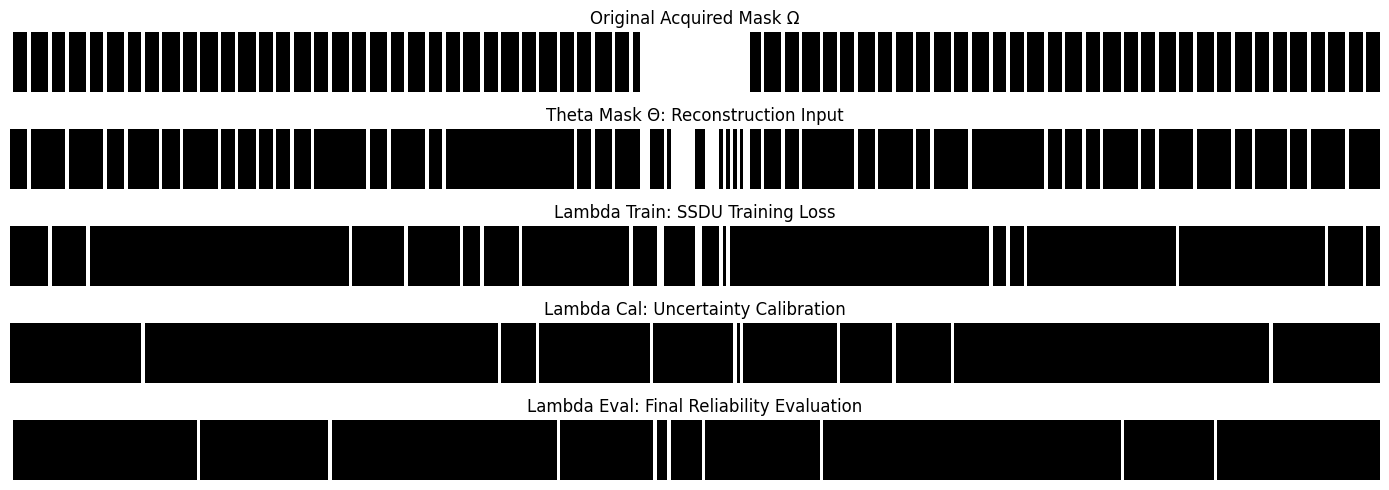

In [9]:
plt.figure(figsize=(14, 5))

plt.subplot(5, 1, 1)
plt.imshow(mask[None, :], cmap="gray", aspect="auto")
plt.title("Original Acquired Mask Ω")
plt.axis("off")

plt.subplot(5, 1, 2)
plt.imshow(theta_mask[None, :], cmap="gray", aspect="auto")
plt.title("Theta Mask Θ: Reconstruction Input")
plt.axis("off")

plt.subplot(5, 1, 3)
plt.imshow(lambda_train_mask[None, :], cmap="gray", aspect="auto")
plt.title("Lambda Train: SSDU Training Loss")
plt.axis("off")

plt.subplot(5, 1, 4)
plt.imshow(lambda_cal_mask[None, :], cmap="gray", aspect="auto")
plt.title("Lambda Cal: Uncertainty Calibration")
plt.axis("off")

plt.subplot(5, 1, 5)
plt.imshow(lambda_eval_mask[None, :], cmap="gray", aspect="auto")
plt.title("Lambda Eval: Final Reliability Evaluation")
plt.axis("off")

plt.tight_layout()
plt.show()

#**Train on Lambda_train, evaluate on Lambda_cal and Lambda_eval**

In [10]:
def run_four_way_reliability_experiment(
    kspace,
    mask,
    slice_index,
    coil_index=0,
    train_fraction=0.2,
    cal_fraction=0.1,
    eval_fraction=0.1,
    split_seed=42,
    model_seed=0,
    num_steps=50,
    num_samples=8,
    features=16,
    dropout_p=0.1,
    lr=1e-4,
    lambda_img=1e7,
):
    """
    Four-way SSDU reliability experiment.

    Train only on Lambda_train.
    Compute uncertainty-residual alignment separately on Lambda_cal and Lambda_eval.
    """

    np.random.seed(model_seed)
    torch.manual_seed(model_seed)

    # Select single-coil slice
    kspace_slice = kspace[slice_index]
    kspace_single = kspace_slice[coil_index]

    # Four-way SSDU split
    theta_mask, lambda_train_mask, lambda_cal_mask, lambda_eval_mask = split_acquired_mask_four_way(
        mask=mask,
        train_fraction=train_fraction,
        cal_fraction=cal_fraction,
        eval_fraction=eval_fraction,
        seed=split_seed,
    )

    # Prepare input from Theta only
    x_input, kspace_theta = prepare_single_coil_ssdu_input(
        kspace_single=kspace_single,
        theta_mask=theta_mask,
        normalize=True,
    )

    # Dropout model
    model = DropoutCNNReconstructor(
        in_channels=1,
        out_channels=1,
        features=features,
        dropout_p=dropout_p,
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    ssdu_history = []
    img_history = []

    model.train()

    for step in range(num_steps):
        optimizer.zero_grad()

        x_pred = model(x_input)

        # Train ONLY on Lambda_train
        total_loss, ssdu_loss, img_loss = total_ssdu_training_loss(
            x_pred_tensor=x_pred,
            x_input_tensor=x_input,
            kspace_single=kspace_single,
            lambda_mask=lambda_train_mask,
            lambda_img=lambda_img,
        )

        total_loss.backward()
        optimizer.step()

        loss_history.append(total_loss.item())
        ssdu_history.append(ssdu_loss.item())
        img_history.append(img_loss.item())

    # Stochastic inference
    stochastic_outputs = stochastic_reconstructions(
        model=model,
        x_input_tensor=x_input,
        num_samples=num_samples,
    )

    mean_image, uncertainty_map = compute_mean_and_uncertainty(stochastic_outputs)

    # Calibration residual energy: Lambda_cal
    residual_energy_cal = backproject_lambda_residual(
        mean_image=mean_image,
        measured_kspace=kspace_single,
        lambda_mask=lambda_cal_mask,
    )

    # Evaluation residual energy: Lambda_eval
    residual_energy_eval = backproject_lambda_residual(
        mean_image=mean_image,
        measured_kspace=kspace_single,
        lambda_mask=lambda_eval_mask,
    )

    alignment_cal = map_alignment(
        uncertainty_map,
        residual_energy_cal,
    )

    alignment_eval = map_alignment(
        uncertainty_map,
        residual_energy_eval,
    )

    result = {
        "slice_index": slice_index,
        "coil_index": coil_index,
        "split_seed": split_seed,
        "model_seed": model_seed,
        "initial_train_ssdu_loss": ssdu_history[0],
        "final_train_ssdu_loss": ssdu_history[-1],
        "train_ssdu_reduction_percent": 100 * (ssdu_history[0] - ssdu_history[-1]) / ssdu_history[0],
        "initial_image_loss": img_history[0],
        "final_image_loss": img_history[-1],
        "alignment_cal": alignment_cal,
        "alignment_eval": alignment_eval,
        "loss_history": loss_history,
        "ssdu_history": ssdu_history,
        "img_history": img_history,
        "mean_image": mean_image,
        "uncertainty_map": uncertainty_map,
        "residual_energy_cal": residual_energy_cal,
        "residual_energy_eval": residual_energy_eval,
        "x_input": x_input.detach().cpu().numpy()[0, 0],
    }

    return result

**test it on slice 8 first:**

In [11]:
four_way_result_8 = run_four_way_reliability_experiment(
    kspace=kspace,
    mask=mask,
    slice_index=8,
    coil_index=0,
    split_seed=42,
    model_seed=0,
    num_steps=50,
    num_samples=8,
)

print("Slice:", four_way_result_8["slice_index"])
print("Initial train SSDU loss:", four_way_result_8["initial_train_ssdu_loss"])
print("Final train SSDU loss:", four_way_result_8["final_train_ssdu_loss"])
print("Training SSDU reduction %:", four_way_result_8["train_ssdu_reduction_percent"])
print("Calibration alignment:", four_way_result_8["alignment_cal"])
print("Evaluation alignment:", four_way_result_8["alignment_eval"])

Slice: 8
Initial train SSDU loss: 34236328.0
Final train SSDU loss: 20935760.0
Training SSDU reduction %: 38.849283135738155
Calibration alignment: 0.4237924124864184
Evaluation alignment: 0.5121614380155773


**Run four-way split across multiple slices**

In [12]:
four_way_multi_slice_results = []

for slice_index in [4, 8, 12]:
    print(f"\nRunning four-way experiment on slice {slice_index}...")

    result = run_four_way_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        train_fraction=0.2,
        cal_fraction=0.1,
        eval_fraction=0.1,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    four_way_multi_slice_results.append({
        "slice_index": slice_index,
        "initial_train_ssdu_loss": result["initial_train_ssdu_loss"],
        "final_train_ssdu_loss": result["final_train_ssdu_loss"],
        "train_ssdu_reduction_percent": result["train_ssdu_reduction_percent"],
        "alignment_cal": result["alignment_cal"],
        "alignment_eval": result["alignment_eval"],
    })

four_way_multi_slice_df = pd.DataFrame(four_way_multi_slice_results)
four_way_multi_slice_df


Running four-way experiment on slice 4...

Running four-way experiment on slice 8...

Running four-way experiment on slice 12...


,slice_index,initial_train_ssdu_loss,final_train_ssdu_loss,train_ssdu_reduction_percent,alignment_cal,alignment_eval
0,4,77422928.0,40357816.0,47.873560,0.392745,0.404839
1,8,34236328.0,20935760.0,38.849283,0.423792,0.512161
2,12,55932464.0,35439100.0,36.639480,0.432562,0.518162


In [13]:
print(four_way_multi_slice_df)

print("\nMean training SSDU reduction %:", four_way_multi_slice_df["train_ssdu_reduction_percent"].mean())
print("Std training SSDU reduction %:", four_way_multi_slice_df["train_ssdu_reduction_percent"].std())

print("\nMean calibration alignment:", four_way_multi_slice_df["alignment_cal"].mean())
print("Std calibration alignment:", four_way_multi_slice_df["alignment_cal"].std())

print("\nMean evaluation alignment:", four_way_multi_slice_df["alignment_eval"].mean())
print("Std evaluation alignment:", four_way_multi_slice_df["alignment_eval"].std())
print("Min evaluation alignment:", four_way_multi_slice_df["alignment_eval"].min())
print("Max evaluation alignment:", four_way_multi_slice_df["alignment_eval"].max())

   slice_index  initial_train_ssdu_loss  final_train_ssdu_loss  \
0            4               77422928.0             40357816.0   
1            8               34236328.0             20935760.0   
2           12               55932464.0             35439100.0   

   train_ssdu_reduction_percent  alignment_cal  alignment_eval  
0                     47.873560       0.392745        0.404839  
1                     38.849283       0.423792        0.512161  
2                     36.639480       0.432562        0.518162  

Mean training SSDU reduction %: 41.120774449377706
Std training SSDU reduction %: 5.951545459625913

Mean calibration alignment: 0.4163666003789969
Std calibration alignment: 0.020921128027440235

Mean evaluation alignment: 0.47838748294110234
Std evaluation alignment: 0.0637655234827069
Min evaluation alignment: 0.40483894917749425
Max evaluation alignment: 0.5181620616302354


#**Test src/four_way_reliability.py**

In [6]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


In [7]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import four_way_reliability
importlib.reload(four_way_reliability)

from four_way_reliability import run_four_way_reliability_experiment

print("four_way_reliability.py imported successfully.")

four_way_reliability.py imported successfully.


**test it on slice 8:**

In [8]:
test_four_way_result = run_four_way_reliability_experiment(
    kspace=kspace,
    mask=mask,
    slice_index=8,
    coil_index=0,
    train_fraction=0.2,
    cal_fraction=0.1,
    eval_fraction=0.1,
    split_seed=42,
    model_seed=0,
    num_steps=50,
    num_samples=8,
    features=16,
    dropout_p=0.1,
    lr=1e-4,
    lambda_img=1e7,
)

print("Slice:", test_four_way_result["slice_index"])
print("Initial train SSDU loss:", test_four_way_result["initial_train_ssdu_loss"])
print("Final train SSDU loss:", test_four_way_result["final_train_ssdu_loss"])
print("Training SSDU reduction %:", test_four_way_result["train_ssdu_reduction_percent"])
print("Calibration alignment:", test_four_way_result["alignment_cal"])
print("Evaluation alignment:", test_four_way_result["alignment_eval"])

Slice: 8
Initial train SSDU loss: 34236328.0
Final train SSDU loss: 20935760.0
Training SSDU reduction %: 38.849283135738155
Calibration alignment: 0.4237925426958646
Evaluation alignment: 0.5121615600507005


#**Run four-way reliability test on all 16 slices**

In [9]:
all_slice_results = []

for slice_index in range(kspace.shape[0]):
    print(f"\nRunning four-way experiment on slice {slice_index}...")

    result = run_four_way_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        train_fraction=0.2,
        cal_fraction=0.1,
        eval_fraction=0.1,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    all_slice_results.append({
        "slice_index": slice_index,
        "initial_train_ssdu_loss": result["initial_train_ssdu_loss"],
        "final_train_ssdu_loss": result["final_train_ssdu_loss"],
        "train_ssdu_reduction_percent": result["train_ssdu_reduction_percent"],
        "alignment_cal": result["alignment_cal"],
        "alignment_eval": result["alignment_eval"],
    })

all_slice_df = pd.DataFrame(all_slice_results)
all_slice_df


Running four-way experiment on slice 0...

Running four-way experiment on slice 1...

Running four-way experiment on slice 2...

Running four-way experiment on slice 3...

Running four-way experiment on slice 4...

Running four-way experiment on slice 5...

Running four-way experiment on slice 6...

Running four-way experiment on slice 7...

Running four-way experiment on slice 8...

Running four-way experiment on slice 9...

Running four-way experiment on slice 10...

Running four-way experiment on slice 11...

Running four-way experiment on slice 12...

Running four-way experiment on slice 13...

Running four-way experiment on slice 14...

Running four-way experiment on slice 15...


,slice_index,initial_train_ssdu_loss,final_train_ssdu_loss,train_ssdu_reduction_percent,alignment_cal,alignment_eval
0,0,195396224.0,88244464.0,54.838194,0.334921,0.381174
1,1,252891232.0,124315192.0,50.842427,0.355052,0.413082
2,2,134028280.0,67938600.0,49.310250,0.375022,0.438849
3,3,86146960.0,44620792.0,48.203869,0.343066,0.453341
4,4,77422920.0,40357816.0,47.873555,0.392746,0.404839
5,5,70205912.0,37586504.0,46.462480,0.347724,0.458414
6,6,36439496.0,21719716.0,40.395125,0.391535,0.446922
7,7,41045204.0,24071168.0,41.354493,0.371006,0.466606
8,8,34236328.0,20935760.0,38.849283,0.423793,0.512162
9,9,39558752.0,24140456.0,38.975689,0.428911,0.502314


In [10]:
print(all_slice_df)

print("\nMean training SSDU reduction %:", all_slice_df["train_ssdu_reduction_percent"].mean())
print("Std training SSDU reduction %:", all_slice_df["train_ssdu_reduction_percent"].std())

print("\nMean calibration alignment:", all_slice_df["alignment_cal"].mean())
print("Std calibration alignment:", all_slice_df["alignment_cal"].std())
print("Min calibration alignment:", all_slice_df["alignment_cal"].min())
print("Max calibration alignment:", all_slice_df["alignment_cal"].max())

print("\nMean evaluation alignment:", all_slice_df["alignment_eval"].mean())
print("Std evaluation alignment:", all_slice_df["alignment_eval"].std())
print("Min evaluation alignment:", all_slice_df["alignment_eval"].min())
print("Max evaluation alignment:", all_slice_df["alignment_eval"].max())

    slice_index  initial_train_ssdu_loss  final_train_ssdu_loss  \
0             0              195396224.0             88244464.0   
1             1              252891232.0            124315192.0   
2             2              134028280.0             67938600.0   
3             3               86146960.0             44620792.0   
4             4               77422920.0             40357816.0   
5             5               70205912.0             37586504.0   
6             6               36439496.0             21719716.0   
7             7               41045204.0             24071168.0   
8             8               34236328.0             20935760.0   
9             9               39558752.0             24140456.0   
10           10               38363132.0             23740318.0   
11           11               50481560.0             31555356.0   
12           12               55932456.0             35439108.0   
13           13               73542904.0             48026880.

#**Baseline-controlled four-way reliability evaluation**

In [12]:
def gradient_magnitude(image):
    """
    Compute simple gradient magnitude from a 2D image.
    """
    gy, gx = np.gradient(image)
    return np.sqrt(gx**2 + gy**2)


baseline_results = []

rng = np.random.default_rng(42)

for slice_index in range(kspace.shape[0]):
    print(f"\nRunning baseline-controlled experiment on slice {slice_index}...")

    result = run_four_way_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        train_fraction=0.2,
        cal_fraction=0.1,
        eval_fraction=0.1,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    residual_eval = result["residual_energy_eval"]
    uncertainty_map = result["uncertainty_map"]
    mean_image = result["mean_image"]
    x_input = result["x_input"]

    random_map = rng.random(residual_eval.shape)
    intensity_map = np.abs(mean_image)
    input_intensity_map = np.abs(x_input)
    edge_map = gradient_magnitude(mean_image)

    baseline_results.append({
        "slice_index": slice_index,
        "random_alignment": map_alignment(random_map, residual_eval),
        "input_intensity_alignment": map_alignment(input_intensity_map, residual_eval),
        "mean_intensity_alignment": map_alignment(intensity_map, residual_eval),
        "edge_alignment": map_alignment(edge_map, residual_eval),
        "dropout_uncertainty_alignment": map_alignment(uncertainty_map, residual_eval),
    })

baseline_df = pd.DataFrame(baseline_results)
baseline_df


Running baseline-controlled experiment on slice 0...

Running baseline-controlled experiment on slice 1...

Running baseline-controlled experiment on slice 2...

Running baseline-controlled experiment on slice 3...

Running baseline-controlled experiment on slice 4...

Running baseline-controlled experiment on slice 5...

Running baseline-controlled experiment on slice 6...

Running baseline-controlled experiment on slice 7...

Running baseline-controlled experiment on slice 8...

Running baseline-controlled experiment on slice 9...

Running baseline-controlled experiment on slice 10...

Running baseline-controlled experiment on slice 11...

Running baseline-controlled experiment on slice 12...

Running baseline-controlled experiment on slice 13...

Running baseline-controlled experiment on slice 14...

Running baseline-controlled experiment on slice 15...


,slice_index,random_alignment,input_intensity_alignment,mean_intensity_alignment,edge_alignment,dropout_uncertainty_alignment
0,0,-0.001131,0.478424,0.415558,0.303639,0.381174
1,1,-0.001883,0.491943,0.433852,0.319824,0.413082
2,2,0.000843,0.536322,0.431318,0.368996,0.438849
3,3,-0.000795,0.554698,0.450208,0.370511,0.453341
4,4,0.004495,0.495757,0.414697,0.334013,0.404839
5,5,0.000631,0.553531,0.448762,0.396892,0.458414
6,6,-0.001171,0.537193,0.462351,0.402467,0.446922
7,7,0.000133,0.546951,0.454261,0.401722,0.466606
8,8,-0.001885,0.588534,0.489111,0.453678,0.512162
9,9,-0.000154,0.579916,0.482784,0.417486,0.502314


In [13]:
print(baseline_df)

summary = baseline_df.drop(columns=["slice_index"]).agg(["mean", "std", "min", "max"]).T
summary

    slice_index  random_alignment  input_intensity_alignment  \
0             0         -0.001131                   0.478424   
1             1         -0.001883                   0.491943   
2             2          0.000843                   0.536322   
3             3         -0.000795                   0.554698   
4             4          0.004495                   0.495757   
5             5          0.000631                   0.553531   
6             6         -0.001171                   0.537193   
7             7          0.000133                   0.546951   
8             8         -0.001885                   0.588534   
9             9         -0.000154                   0.579916   
10           10         -0.000073                   0.557620   
11           11          0.003698                   0.539779   
12           12         -0.000096                   0.585153   
13           13         -0.000106                   0.568752   
14           14          0.001043       

,mean,std,min,max
random_alignment,0.000277,0.001753,-0.001885,0.004495
input_intensity_alignment,0.552900,0.040571,0.478424,0.625273
mean_intensity_alignment,0.459942,0.036685,0.414697,0.547403
edge_alignment,0.394552,0.045329,0.303639,0.467798
dropout_uncertainty_alignment,0.470354,0.045251,0.381174,0.535252


**Compute baseline margins**

In [14]:
baseline_margin_df = baseline_df.copy()

baseline_margin_df["dropout_minus_random"] = (
    baseline_margin_df["dropout_uncertainty_alignment"]
    - baseline_margin_df["random_alignment"]
)

baseline_margin_df["dropout_minus_input_intensity"] = (
    baseline_margin_df["dropout_uncertainty_alignment"]
    - baseline_margin_df["input_intensity_alignment"]
)

baseline_margin_df["dropout_minus_mean_intensity"] = (
    baseline_margin_df["dropout_uncertainty_alignment"]
    - baseline_margin_df["mean_intensity_alignment"]
)

baseline_margin_df["dropout_minus_edge"] = (
    baseline_margin_df["dropout_uncertainty_alignment"]
    - baseline_margin_df["edge_alignment"]
)

baseline_margin_df[
    [
        "slice_index",
        "dropout_minus_random",
        "dropout_minus_input_intensity",
        "dropout_minus_mean_intensity",
        "dropout_minus_edge",
    ]
]

,slice_index,dropout_minus_random,dropout_minus_input_intensity,dropout_minus_mean_intensity,dropout_minus_edge
0,0,0.382305,-0.097250,-0.034384,0.077535
1,1,0.414965,-0.078861,-0.020770,0.093258
2,2,0.438007,-0.097473,0.007531,0.069853
3,3,0.454136,-0.101358,0.003133,0.082829
4,4,0.400345,-0.090918,-0.009858,0.070826
5,5,0.457783,-0.095117,0.009652,0.061522
6,6,0.448093,-0.090271,-0.015428,0.044455
7,7,0.466473,-0.080345,0.012346,0.064884
8,8,0.514047,-0.076373,0.023050,0.058483
9,9,0.502468,-0.077602,0.019530,0.084828


In [15]:
margin_summary = baseline_margin_df[
    [
        "dropout_minus_random",
        "dropout_minus_input_intensity",
        "dropout_minus_mean_intensity",
        "dropout_minus_edge",
    ]
].agg(["mean", "std", "min", "max"]).T

margin_summary

,mean,std,min,max
dropout_minus_random,0.470077,0.045315,0.382305,0.534209
dropout_minus_input_intensity,-0.082546,0.014843,-0.107263,-0.057987
dropout_minus_mean_intensity,0.010412,0.027569,-0.034384,0.055404
dropout_minus_edge,0.075802,0.020927,0.044455,0.113939


#**Partial correlation analysis**

In [16]:
def partial_correlation_with_controls(target_map, predictor_map, control_maps):
    """
    Compute partial correlation between predictor_map and target_map
    after removing linear effects of control_maps.

    target_map: residual energy map
    predictor_map: uncertainty map
    control_maps: list of maps, e.g. [input_intensity, edge_map]
    """
    y = normalize_map(target_map).ravel()
    x = normalize_map(predictor_map).ravel()

    controls = [normalize_map(c).ravel() for c in control_maps]
    C = np.stack(controls, axis=1)

    # Add intercept
    C = np.concatenate([np.ones((C.shape[0], 1)), C], axis=1)

    # Residualize y against controls
    beta_y, *_ = np.linalg.lstsq(C, y, rcond=None)
    y_res = y - C @ beta_y

    # Residualize x against controls
    beta_x, *_ = np.linalg.lstsq(C, x, rcond=None)
    x_res = x - C @ beta_x

    if np.std(y_res) == 0 or np.std(x_res) == 0:
        return 0.0

    return np.corrcoef(x_res, y_res)[0, 1]

**rerun the all-slice experiment with partial correlation:**

In [17]:
partial_results = []

for slice_index in range(kspace.shape[0]):
    print(f"\nRunning partial-correlation experiment on slice {slice_index}...")

    result = run_four_way_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        train_fraction=0.2,
        cal_fraction=0.1,
        eval_fraction=0.1,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    residual_eval = result["residual_energy_eval"]
    uncertainty_map = result["uncertainty_map"]
    mean_image = result["mean_image"]
    x_input = result["x_input"]

    input_intensity = np.abs(x_input)
    mean_intensity = np.abs(mean_image)
    edge_map = gradient_magnitude(mean_image)

    raw_dropout_alignment = map_alignment(
        uncertainty_map,
        residual_eval
    )

    partial_input_edge = partial_correlation_with_controls(
        target_map=residual_eval,
        predictor_map=uncertainty_map,
        control_maps=[input_intensity, edge_map]
    )

    partial_input_mean_edge = partial_correlation_with_controls(
        target_map=residual_eval,
        predictor_map=uncertainty_map,
        control_maps=[input_intensity, mean_intensity, edge_map]
    )

    partial_results.append({
        "slice_index": slice_index,
        "raw_dropout_alignment": raw_dropout_alignment,
        "partial_control_input_edge": partial_input_edge,
        "partial_control_input_mean_edge": partial_input_mean_edge,
    })

partial_df = pd.DataFrame(partial_results)
partial_df


Running partial-correlation experiment on slice 0...

Running partial-correlation experiment on slice 1...

Running partial-correlation experiment on slice 2...

Running partial-correlation experiment on slice 3...

Running partial-correlation experiment on slice 4...

Running partial-correlation experiment on slice 5...

Running partial-correlation experiment on slice 6...

Running partial-correlation experiment on slice 7...

Running partial-correlation experiment on slice 8...

Running partial-correlation experiment on slice 9...

Running partial-correlation experiment on slice 10...

Running partial-correlation experiment on slice 11...

Running partial-correlation experiment on slice 12...

Running partial-correlation experiment on slice 13...

Running partial-correlation experiment on slice 14...

Running partial-correlation experiment on slice 15...


,slice_index,raw_dropout_alignment,partial_control_input_edge,partial_control_input_mean_edge
0,0,0.381174,0.073196,0.071740
1,1,0.413082,0.074840,0.072704
2,2,0.438849,0.063527,0.057802
3,3,0.453341,0.060433,0.053263
4,4,0.404839,0.049602,0.044119
5,5,0.458414,0.062420,0.053354
6,6,0.446922,0.036544,0.032893
7,7,0.466606,0.055222,0.044953
8,8,0.512162,0.059634,0.046297
9,9,0.502314,0.053606,0.038432


In [18]:
print(partial_df)

partial_summary = partial_df.drop(columns=["slice_index"]).agg(
    ["mean", "std", "min", "max"]
).T

partial_summary

    slice_index  raw_dropout_alignment  partial_control_input_edge  \
0             0               0.381174                    0.073196   
1             1               0.413082                    0.074840   
2             2               0.438849                    0.063527   
3             3               0.453341                    0.060433   
4             4               0.404839                    0.049602   
5             5               0.458414                    0.062420   
6             6               0.446922                    0.036544   
7             7               0.466606                    0.055222   
8             8               0.512162                    0.059634   
9             9               0.502314                    0.053606   
10           10               0.491335                    0.062980   
11           11               0.481792                    0.058469   
12           12               0.518162                    0.045843   
13           13     

,mean,std,min,max
raw_dropout_alignment,0.470354,0.045251,0.381174,0.535252
partial_control_input_edge,0.056158,0.013597,0.029635,0.075172
partial_control_input_mean_edge,0.047367,0.017518,0.015509,0.081819


#**Define calibration utilities**

In [19]:
def flatten_norm(x, eps=1e-12):
    """
    Normalize a 2D map to [0, 1] and flatten it.
    """
    x = np.asarray(x)
    x = np.abs(x)
    return ((x - x.min()) / (x.max() - x.min() + eps)).ravel()


def fit_ridge_reliability_map(
    target_map,
    predictor_maps,
    output_shape,
    ridge_lambda=1e-3,
):
    """
    Fit a simple ridge regression reliability map.

    target_map:
        Calibration residual energy map.

    predictor_maps:
        List of predictor maps, for example:
        [dropout_uncertainty, input_intensity, edge_map]

    output_shape:
        Shape of the output 2D reliability map.

    ridge_lambda:
        Small ridge penalty for numerical stability.
    """
    y = flatten_norm(target_map)

    X_list = [flatten_norm(p) for p in predictor_maps]
    X = np.stack(X_list, axis=1)

    # Add intercept
    X = np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)

    # Ridge regression: beta = (X^T X + lambda I)^-1 X^T y
    I = np.eye(X.shape[1])
    I[0, 0] = 0.0  # do not penalize intercept

    beta = np.linalg.solve(
        X.T @ X + ridge_lambda * I,
        X.T @ y
    )

    pred = X @ beta
    reliability_map = pred.reshape(output_shape)

    return reliability_map, beta

**Test calibrated reliability on one slice first**

In [20]:
cal_test_result = run_four_way_reliability_experiment(
    kspace=kspace,
    mask=mask,
    slice_index=8,
    coil_index=0,
    train_fraction=0.2,
    cal_fraction=0.1,
    eval_fraction=0.1,
    split_seed=42,
    model_seed=0,
    num_steps=50,
    num_samples=8,
    features=16,
    dropout_p=0.1,
    lr=1e-4,
    lambda_img=1e7,
)

residual_cal = cal_test_result["residual_energy_cal"]
residual_eval = cal_test_result["residual_energy_eval"]

U = cal_test_result["uncertainty_map"]
x_input = cal_test_result["x_input"]
mean_image = cal_test_result["mean_image"]

I_input = np.abs(x_input)
I_mean = np.abs(mean_image)
G = gradient_magnitude(mean_image)

# Structural calibrated baseline: intensity + edge only
R_struct, beta_struct = fit_ridge_reliability_map(
    target_map=residual_cal,
    predictor_maps=[I_input, G],
    output_shape=residual_cal.shape,
    ridge_lambda=1e-3,
)

# Hybrid calibrated reliability: dropout uncertainty + intensity + edge
R_hybrid, beta_hybrid = fit_ridge_reliability_map(
    target_map=residual_cal,
    predictor_maps=[U, I_input, G],
    output_shape=residual_cal.shape,
    ridge_lambda=1e-3,
)

# Compare on Lambda_eval only
raw_dropout_eval = map_alignment(U, residual_eval)
input_intensity_eval = map_alignment(I_input, residual_eval)
edge_eval = map_alignment(G, residual_eval)
struct_eval = map_alignment(R_struct, residual_eval)
hybrid_eval = map_alignment(R_hybrid, residual_eval)

print("Raw dropout eval alignment:", raw_dropout_eval)
print("Input intensity eval alignment:", input_intensity_eval)
print("Edge eval alignment:", edge_eval)
print("Calibrated structural eval alignment:", struct_eval)
print("Calibrated hybrid eval alignment:", hybrid_eval)

print("\nBeta structural:", beta_struct)
print("Beta hybrid:", beta_hybrid)

Raw dropout eval alignment: 0.5121615600507005
Input intensity eval alignment: 0.5885340616236794
Edge eval alignment: 0.4536780984171506
Calibrated structural eval alignment: 0.5936402395496507
Calibrated hybrid eval alignment: 0.5945852136655957

Beta structural: [-0.00387491  0.3059537   0.04965099]
Beta hybrid: [-0.01076194  0.02358471  0.29513808  0.04922765]


**residual-calibrated reliability across all slices**

In [21]:
calibrated_results = []

for slice_index in range(kspace.shape[0]):
    print(f"\nRunning calibrated reliability experiment on slice {slice_index}...")

    result = run_four_way_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        train_fraction=0.2,
        cal_fraction=0.1,
        eval_fraction=0.1,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    residual_cal = result["residual_energy_cal"]
    residual_eval = result["residual_energy_eval"]

    U = result["uncertainty_map"]
    x_input = result["x_input"]
    mean_image = result["mean_image"]

    I_input = np.abs(x_input)
    I_mean = np.abs(mean_image)
    G = gradient_magnitude(mean_image)

    # Structural calibrated baseline: input intensity + edge
    R_struct, beta_struct = fit_ridge_reliability_map(
        target_map=residual_cal,
        predictor_maps=[I_input, G],
        output_shape=residual_cal.shape,
        ridge_lambda=1e-3,
    )

    # Hybrid calibrated reliability: dropout uncertainty + input intensity + edge
    R_hybrid, beta_hybrid = fit_ridge_reliability_map(
        target_map=residual_cal,
        predictor_maps=[U, I_input, G],
        output_shape=residual_cal.shape,
        ridge_lambda=1e-3,
    )

    raw_dropout_eval = map_alignment(U, residual_eval)
    input_intensity_eval = map_alignment(I_input, residual_eval)
    mean_intensity_eval = map_alignment(I_mean, residual_eval)
    edge_eval = map_alignment(G, residual_eval)
    struct_eval = map_alignment(R_struct, residual_eval)
    hybrid_eval = map_alignment(R_hybrid, residual_eval)

    calibrated_results.append({
        "slice_index": slice_index,
        "raw_dropout_eval": raw_dropout_eval,
        "input_intensity_eval": input_intensity_eval,
        "mean_intensity_eval": mean_intensity_eval,
        "edge_eval": edge_eval,
        "struct_calibrated_eval": struct_eval,
        "hybrid_calibrated_eval": hybrid_eval,
        "hybrid_minus_dropout": hybrid_eval - raw_dropout_eval,
        "hybrid_minus_input": hybrid_eval - input_intensity_eval,
        "hybrid_minus_struct": hybrid_eval - struct_eval,
        "beta_U": beta_hybrid[1],
        "beta_input": beta_hybrid[2],
        "beta_edge": beta_hybrid[3],
    })

calibrated_df = pd.DataFrame(calibrated_results)
calibrated_df


Running calibrated reliability experiment on slice 0...

Running calibrated reliability experiment on slice 1...

Running calibrated reliability experiment on slice 2...

Running calibrated reliability experiment on slice 3...

Running calibrated reliability experiment on slice 4...

Running calibrated reliability experiment on slice 5...

Running calibrated reliability experiment on slice 6...

Running calibrated reliability experiment on slice 7...

Running calibrated reliability experiment on slice 8...

Running calibrated reliability experiment on slice 9...

Running calibrated reliability experiment on slice 10...

Running calibrated reliability experiment on slice 11...

Running calibrated reliability experiment on slice 12...

Running calibrated reliability experiment on slice 13...

Running calibrated reliability experiment on slice 14...

Running calibrated reliability experiment on slice 15...


,slice_index,raw_dropout_eval,input_intensity_eval,mean_intensity_eval,edge_eval,struct_calibrated_eval,hybrid_calibrated_eval,hybrid_minus_dropout,hybrid_minus_input,hybrid_minus_struct,beta_U,beta_input,beta_edge
0,0,0.381174,0.478424,0.415558,0.303639,0.482400,0.485981,0.104807,0.007557,0.003581,0.049486,0.235665,0.060107
1,1,0.413082,0.491943,0.433852,0.319824,0.494262,0.498170,0.085087,0.006227,0.003908,0.091797,0.228951,0.146319
2,2,0.438849,0.536322,0.431318,0.368996,0.541539,0.544126,0.105277,0.007804,0.002587,0.061812,0.209644,0.056991
3,3,0.453341,0.554698,0.450208,0.370511,0.559615,0.560852,0.107511,0.006153,0.001237,0.031779,0.343018,0.127870
4,4,0.404839,0.495757,0.414697,0.334013,0.498383,0.500235,0.095395,0.004478,0.001852,0.056033,0.274048,0.038849
5,5,0.458414,0.553531,0.448762,0.396892,0.555065,0.556637,0.098223,0.003106,0.001572,0.034496,0.281592,0.011520
6,6,0.446922,0.537193,0.462351,0.402467,0.540616,0.541473,0.094551,0.004280,0.000857,0.037518,0.276598,0.036647
7,7,0.466606,0.546951,0.454261,0.401722,0.548564,0.549625,0.083019,0.002673,0.001061,0.032979,0.340219,0.020809
8,8,0.512162,0.588534,0.489111,0.453678,0.593640,0.594585,0.082424,0.006051,0.000945,0.023585,0.295138,0.049228
9,9,0.502314,0.579916,0.482784,0.417486,0.583694,0.584205,0.081891,0.004289,0.000511,0.016511,0.386742,0.078288


In [22]:
print(calibrated_df)

calibrated_summary = calibrated_df.drop(columns=["slice_index"]).agg(
    ["mean", "std", "min", "max"]
).T

calibrated_summary

    slice_index  raw_dropout_eval  input_intensity_eval  mean_intensity_eval  \
0             0          0.381174              0.478424             0.415558   
1             1          0.413082              0.491943             0.433852   
2             2          0.438849              0.536322             0.431318   
3             3          0.453341              0.554698             0.450208   
4             4          0.404839              0.495757             0.414697   
5             5          0.458414              0.553531             0.448762   
6             6          0.446922              0.537193             0.462351   
7             7          0.466606              0.546951             0.454261   
8             8          0.512162              0.588534             0.489111   
9             9          0.502314              0.579916             0.482784   
10           10          0.491335              0.557620             0.435931   
11           11          0.481792       

,mean,std,min,max
raw_dropout_eval,0.470354,0.045251,0.381174,0.535252
input_intensity_eval,0.552900,0.040571,0.478424,0.625273
mean_intensity_eval,0.459942,0.036685,0.414697,0.547403
edge_eval,0.394552,0.045329,0.303639,0.467798
struct_calibrated_eval,0.557906,0.042037,0.482400,0.636130
hybrid_calibrated_eval,0.559571,0.041464,0.485981,0.638742
hybrid_minus_dropout,0.089217,0.015198,0.065077,0.120732
hybrid_minus_input,0.006671,0.004148,-0.000260,0.014063
hybrid_minus_struct,0.001665,0.001058,0.000413,0.003908
beta_U,0.050111,0.021424,0.016511,0.091797


#**Test src/calibration.py**

In [23]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 28 (delta 9), reused 5 (delta 5), pack-reused 13 (from 1)
Unpacking objects: 100% (28/28), 71.08 KiB | 454.00 KiB/s, done.
From https://github.com/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri
   e9d6920..aca9b63  main       -> origin/main
Updating e9d6920..aca9b63
Fast-forward
 ...xperiment_020_all_slice_four_way_reliability.md |  179 +
 ...021_baseline_controlled_reliability_analysis.md |  196 +
 ...ment_022_residual_calibrated_reliability_map.md |  191 +
 notebooks/03_multi_slice_reliability_check.ipynb   | 3949 +++++++++++++++++++-
 src/calibration.py                                 |  189 +
 5 files changed, 4660 insertions(+), 44 deletions(-)
 create mode 100644 experiments/experiment_020_all_slice_four_way_reliability.md
 create mode 100644 experiments/experiment_021_baseline_controlled_reliabilit

In [24]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import calibration
importlib.reload(calibration)

from calibration import (
    gradient_magnitude,
    fit_structural_reliability_map,
    fit_hybrid_reliability_map,
)

print("calibration.py imported successfully.")

calibration.py imported successfully.


**test it on slice 8:**

In [25]:
cal_util_result = run_four_way_reliability_experiment(
    kspace=kspace,
    mask=mask,
    slice_index=8,
    coil_index=0,
    train_fraction=0.2,
    cal_fraction=0.1,
    eval_fraction=0.1,
    split_seed=42,
    model_seed=0,
    num_steps=50,
    num_samples=8,
    features=16,
    dropout_p=0.1,
    lr=1e-4,
    lambda_img=1e7,
)

residual_cal = cal_util_result["residual_energy_cal"]
residual_eval = cal_util_result["residual_energy_eval"]

U = cal_util_result["uncertainty_map"]
x_input = cal_util_result["x_input"]
mean_image = cal_util_result["mean_image"]

I_input = abs(x_input)
G = gradient_magnitude(mean_image)

R_struct, beta_struct = fit_structural_reliability_map(
    residual_cal=residual_cal,
    input_image=x_input,
    mean_image=mean_image,
    ridge_lambda=1e-3,
)

R_hybrid, beta_hybrid = fit_hybrid_reliability_map(
    residual_cal=residual_cal,
    uncertainty_map=U,
    input_image=x_input,
    mean_image=mean_image,
    ridge_lambda=1e-3,
)

raw_dropout_eval = map_alignment(U, residual_eval)
input_intensity_eval = map_alignment(I_input, residual_eval)
edge_eval = map_alignment(G, residual_eval)
struct_eval = map_alignment(R_struct, residual_eval)
hybrid_eval = map_alignment(R_hybrid, residual_eval)

print("Raw dropout eval alignment:", raw_dropout_eval)
print("Input intensity eval alignment:", input_intensity_eval)
print("Edge eval alignment:", edge_eval)
print("Structural calibrated eval alignment:", struct_eval)
print("Hybrid calibrated eval alignment:", hybrid_eval)

print("\nBeta structural:", beta_struct)
print("Beta hybrid:", beta_hybrid)

Raw dropout eval alignment: 0.5121615600507005
Input intensity eval alignment: 0.5885340616236794
Edge eval alignment: 0.4536780984171506
Structural calibrated eval alignment: 0.5936402395496507
Hybrid calibrated eval alignment: 0.5945852136655957

Beta structural: [-0.00387491  0.3059537   0.04965099]
Beta hybrid: [-0.01076194  0.02358471  0.29513808  0.04922765]


#**Test the heteroscedastic CNN model**

In [26]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 14 (delta 9), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (14/14), 4.37 KiB | 172.00 KiB/s, done.
From https://github.com/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri
   aca9b63..d16c179  main       -> origin/main
Updating aca9b63..d16c179
Fast-forward
 notebooks/03_multi_slice_reliability_check.ipynb | 188 ++++++++++++++++++++++-
 src/models/__init__.py                           |   1 +
 src/models/heteroscedastic_cnn.py                |  91 +++++++++++
 3 files changed, 278 insertions(+), 2 deletions(-)
 create mode 100644 src/models/heteroscedastic_cnn.py


**Import the model:**

In [27]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

from models.heteroscedastic_cnn import HeteroscedasticCNNReconstructor

print("HeteroscedasticCNNReconstructor imported successfully.")

HeteroscedasticCNNReconstructor imported successfully.


**prepare a test input from slice 8:**

In [28]:
from ssdu import split_acquired_mask_four_way
from training import prepare_single_coil_ssdu_input

slice_index = 8
coil_index = 0

kspace_single = kspace[slice_index, coil_index]

theta_mask, lambda_train_mask, lambda_cal_mask, lambda_eval_mask = split_acquired_mask_four_way(
    mask=mask,
    train_fraction=0.2,
    cal_fraction=0.1,
    eval_fraction=0.1,
    seed=42
)

x_input_hetero, _ = prepare_single_coil_ssdu_input(
    kspace_single=kspace_single,
    theta_mask=theta_mask,
    normalize=True
)

print("Input shape:", x_input_hetero.shape)

Input shape: torch.Size([1, 1, 768, 396])


**run a forward pass:**

In [29]:
hetero_model = HeteroscedasticCNNReconstructor(
    in_channels=1,
    features=16
)

hetero_model.train()

x_hat, sigma2_hat = hetero_model(x_input_hetero)

print("x_hat shape:", x_hat.shape)
print("sigma2_hat shape:", sigma2_hat.shape)

print("sigma2 min:", sigma2_hat.min().item())
print("sigma2 max:", sigma2_hat.max().item())
print("sigma2 mean:", sigma2_hat.mean().item())

x_hat shape: torch.Size([1, 1, 768, 396])
sigma2_hat shape: torch.Size([1, 1, 768, 396])
sigma2 min: 0.6488534212112427
sigma2 max: 0.6631097793579102
sigma2 mean: 0.6553208231925964


**Define heteroscedastic calibration loss**

In [30]:
from training import torch_fft2c, image_consistency_loss, single_coil_ssdu_loss

def torch_ifft2c(kspace):
    """
    Centered inverse 2D FFT for PyTorch complex tensors.
    """
    image = torch.fft.fftshift(
        torch.fft.ifft2(
            torch.fft.ifftshift(kspace, dim=(-2, -1)),
            norm="ortho"
        ),
        dim=(-2, -1)
    )
    return image


def torch_normalize_map(x, eps=1e-12):
    """
    Normalize tensor map to [0, 1].
    """
    x = torch.abs(x)
    return (x - x.min()) / (x.max() - x.min() + eps)


def lambda_residual_energy_torch(x_hat_tensor, kspace_single, lambda_mask):
    """
    Compute differentiable image-domain residual energy from a Lambda mask.
    """
    x_hat = x_hat_tensor[0, 0]

    k_pred = torch_fft2c(x_hat)

    lambda_mask_2d = lambda_mask[None, :]

    true_lambda = lambda_mask_2d * kspace_single

    true_lambda_torch = torch.from_numpy(true_lambda).to(k_pred.device)
    lambda_mask_torch = torch.from_numpy(lambda_mask_2d).float().to(k_pred.device)

    residual_lambda = lambda_mask_torch * (k_pred - true_lambda_torch)

    residual_img = torch_ifft2c(residual_lambda)

    residual_energy = torch.abs(residual_img) ** 2

    return residual_energy


def heteroscedastic_calibration_loss(
    sigma2_hat,
    residual_energy_cal,
):
    """
    Train sigma2_hat to match normalized calibration residual energy.

    This is a first simple calibration loss.
    """
    sigma_map = sigma2_hat[0, 0]

    sigma_norm = torch_normalize_map(sigma_map)
    residual_norm = torch_normalize_map(residual_energy_cal.detach())

    loss = torch.mean((sigma_norm - residual_norm) ** 2)

    return loss

**Train heteroscedastic model on slice 8**

In [31]:
hetero_model = HeteroscedasticCNNReconstructor(
    in_channels=1,
    features=16
)

optimizer = torch.optim.Adam(hetero_model.parameters(), lr=1e-4)

num_steps = 50
lambda_img = 1e7
lambda_cal = 1e6

hetero_loss_history = []
hetero_ssdu_history = []
hetero_img_history = []
hetero_cal_history = []

hetero_model.train()

for step in range(num_steps):
    optimizer.zero_grad()

    x_hat, sigma2_hat = hetero_model(x_input_hetero)

    # Reconstruction loss only on Lambda_train
    ssdu_loss = single_coil_ssdu_loss(
        x_pred_tensor=x_hat,
        kspace_single=kspace_single,
        lambda_mask=lambda_train_mask,
    )

    # Image consistency
    img_loss = image_consistency_loss(
        x_pred_tensor=x_hat,
        x_input_tensor=x_input_hetero,
    )

    # Calibration residual energy only from Lambda_cal
    residual_energy_cal_torch = lambda_residual_energy_torch(
        x_hat_tensor=x_hat,
        kspace_single=kspace_single,
        lambda_mask=lambda_cal_mask,
    )

    cal_loss = heteroscedastic_calibration_loss(
        sigma2_hat=sigma2_hat,
        residual_energy_cal=residual_energy_cal_torch,
    )

    total_loss = ssdu_loss + lambda_img * img_loss + lambda_cal * cal_loss

    total_loss.backward()
    optimizer.step()

    hetero_loss_history.append(total_loss.item())
    hetero_ssdu_history.append(ssdu_loss.item())
    hetero_img_history.append(img_loss.item())
    hetero_cal_history.append(cal_loss.item())

    if step % 10 == 0 or step == num_steps - 1:
        print(
            f"Step {step:03d} | "
            f"Total: {total_loss.item():.6f} | "
            f"SSDU: {ssdu_loss.item():.6f} | "
            f"Image: {img_loss.item():.6f} | "
            f"Cal: {cal_loss.item():.6f}"
        )

Step 000 | Total: 25489324.000000 | SSDU: 24739064.000000 | Image: 0.065438 | Cal: 0.095880
Step 010 | Total: 21958882.000000 | SSDU: 21299066.000000 | Image: 0.057320 | Cal: 0.086619
Step 020 | Total: 20115912.000000 | SSDU: 19532780.000000 | Image: 0.049856 | Cal: 0.084572
Step 030 | Total: 18554970.000000 | SSDU: 17998916.000000 | Image: 0.048759 | Cal: 0.068465
Step 040 | Total: 16771767.000000 | SSDU: 16223921.000000 | Image: 0.049544 | Cal: 0.052409
Step 049 | Total: 14928573.000000 | SSDU: 14381544.000000 | Image: 0.050291 | Cal: 0.044117


Evaluate learned uncertainty head on Λ
eval
	​
**bold text**

In [32]:
hetero_model.eval()

with torch.no_grad():
    x_hat_hetero, sigma2_hat_hetero = hetero_model(x_input_hetero)

x_hat_hetero_np = x_hat_hetero.detach().cpu().numpy()[0, 0]
sigma2_hetero_np = sigma2_hat_hetero.detach().cpu().numpy()[0, 0]

# Evaluation residual energy from Lambda_eval
residual_eval_hetero = backproject_lambda_residual(
    mean_image=x_hat_hetero_np,
    measured_kspace=kspace_single,
    lambda_mask=lambda_eval_mask
)

# Baseline maps
I_input = np.abs(x_input_hetero.detach().cpu().numpy()[0, 0])
I_hat = np.abs(x_hat_hetero_np)
G_hat = gradient_magnitude(x_hat_hetero_np)

# Alignments
sigma2_eval_alignment = map_alignment(
    sigma2_hetero_np,
    residual_eval_hetero
)

input_intensity_alignment = map_alignment(
    I_input,
    residual_eval_hetero
)

recon_intensity_alignment = map_alignment(
    I_hat,
    residual_eval_hetero
)

edge_alignment = map_alignment(
    G_hat,
    residual_eval_hetero
)

print("Learned sigma2 eval alignment:", sigma2_eval_alignment)
print("Input intensity eval alignment:", input_intensity_alignment)
print("Reconstruction intensity eval alignment:", recon_intensity_alignment)
print("Edge eval alignment:", edge_alignment)

print("\nSigma2 min:", sigma2_hetero_np.min())
print("Sigma2 max:", sigma2_hetero_np.max())
print("Sigma2 mean:", sigma2_hetero_np.mean())
print("Sigma2 std:", sigma2_hetero_np.std())

Learned sigma2 eval alignment: -0.2462225841689998
Input intensity eval alignment: 0.5779430799234127
Reconstruction intensity eval alignment: 0.4574855436263125
Edge eval alignment: 0.4435558791996254

Sigma2 min: 0.7051281
Sigma2 max: 0.73148316
Sigma2 mean: 0.71067494
Sigma2 std: 0.0009846364


**visualize:**

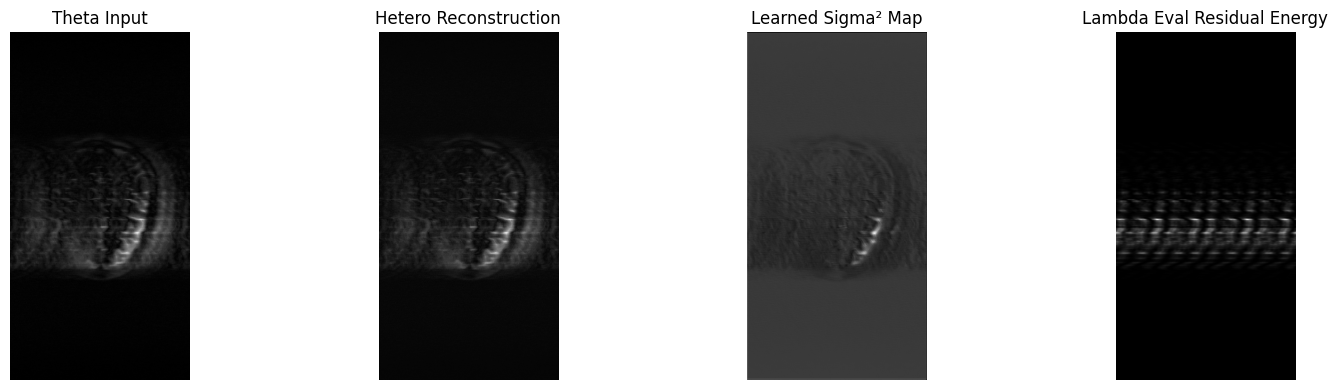

In [33]:
sigma2_norm = normalize_map(sigma2_hetero_np)
residual_eval_norm = normalize_map(residual_eval_hetero)

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(I_input, cmap="gray")
plt.title("Theta Input")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(x_hat_hetero_np, cmap="gray")
plt.title("Hetero Reconstruction")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(sigma2_norm, cmap="gray")
plt.title("Learned Sigma² Map")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(residual_eval_norm, cmap="gray")
plt.title("Lambda Eval Residual Energy")
plt.axis("off")

plt.tight_layout()
plt.show()

**Check whether sigma² learned calibration residual but failed evaluation**

In [35]:
# Compute calibration residual energy from the final hetero reconstruction
residual_cal_hetero = backproject_lambda_residual(
    mean_image=x_hat_hetero_np,
    measured_kspace=kspace_single,
    lambda_mask=lambda_cal_mask
)

sigma2_cal_alignment = map_alignment(
    sigma2_hetero_np,
    residual_cal_hetero
)

sigma2_eval_alignment = map_alignment(
    sigma2_hetero_np,
    residual_eval_hetero
)

input_cal_alignment = map_alignment(
    I_input,
    residual_cal_hetero
)

input_eval_alignment = map_alignment(
    I_input,
    residual_eval_hetero
)

edge_cal_alignment = map_alignment(
    G_hat,
    residual_cal_hetero
)

edge_eval_alignment = map_alignment(
    G_hat,
    residual_eval_hetero
)

print("Sigma² vs Lambda_cal residual:", sigma2_cal_alignment)
print("Sigma² vs Lambda_eval residual:", sigma2_eval_alignment)

print("\nInput intensity vs Lambda_cal residual:", input_cal_alignment)
print("Input intensity vs Lambda_eval residual:", input_eval_alignment)

print("\nEdge vs Lambda_cal residual:", edge_cal_alignment)
print("Edge vs Lambda_eval residual:", edge_eval_alignment)

Sigma² vs Lambda_cal residual: -0.19405060742504324
Sigma² vs Lambda_eval residual: -0.2462225841689998

Input intensity vs Lambda_cal residual: 0.4991804216193169
Input intensity vs Lambda_eval residual: 0.5779430799234127

Edge vs Lambda_cal residual: 0.35012829068311785
Edge vs Lambda_eval residual: 0.4435558791996254


Sigma² vs Lambda_cal residual: -0.19405060742504324
Sigma² vs Lambda_eval residual: -0.2462225841689998

Input intensity vs Lambda_cal residual: 0.4991804216193169
Input intensity vs Lambda_eval residual: 0.5779430799234127

Edge vs Lambda_cal residual: 0.35012829068311785
Edge vs Lambda_eval residual: 0.4435558791996254


**Reinitialize model and train reconstruction only**

In [36]:
hetero_stage_model = HeteroscedasticCNNReconstructor(
    in_channels=1,
    features=16
)

optimizer = torch.optim.Adam(hetero_stage_model.parameters(), lr=1e-4)

num_steps_stage1 = 50
lambda_img = 1e7

stage1_ssdu_history = []
stage1_img_history = []
stage1_total_history = []

hetero_stage_model.train()

for step in range(num_steps_stage1):
    optimizer.zero_grad()

    x_hat, sigma2_hat = hetero_stage_model(x_input_hetero)

    ssdu_loss = single_coil_ssdu_loss(
        x_pred_tensor=x_hat,
        kspace_single=kspace_single,
        lambda_mask=lambda_train_mask,
    )

    img_loss = image_consistency_loss(
        x_pred_tensor=x_hat,
        x_input_tensor=x_input_hetero,
    )

    total_loss = ssdu_loss + lambda_img * img_loss

    total_loss.backward()
    optimizer.step()

    stage1_total_history.append(total_loss.item())
    stage1_ssdu_history.append(ssdu_loss.item())
    stage1_img_history.append(img_loss.item())

    if step % 10 == 0 or step == num_steps_stage1 - 1:
        print(
            f"Stage 1 | Step {step:03d} | "
            f"Total: {total_loss.item():.6f} | "
            f"SSDU: {ssdu_loss.item():.6f} | "
            f"Image: {img_loss.item():.6f}"
        )

Stage 1 | Step 000 | Total: 39463628.000000 | SSDU: 39434660.000000 | Image: 0.002897
Stage 1 | Step 010 | Total: 31329112.000000 | SSDU: 31212396.000000 | Image: 0.011672
Stage 1 | Step 020 | Total: 26522516.000000 | SSDU: 26293606.000000 | Image: 0.022891
Stage 1 | Step 030 | Total: 24087452.000000 | SSDU: 23772948.000000 | Image: 0.031450
Stage 1 | Step 040 | Total: 22479586.000000 | SSDU: 22102080.000000 | Image: 0.037751
Stage 1 | Step 049 | Total: 20806872.000000 | SSDU: 20387188.000000 | Image: 0.041968


**Compute fixed calibration residual target**

In [37]:
hetero_stage_model.eval()

with torch.no_grad():
    x_hat_stage1, sigma2_stage1 = hetero_stage_model(x_input_hetero)

# Fixed calibration residual target from Lambda_cal
residual_cal_fixed = lambda_residual_energy_torch(
    x_hat_tensor=x_hat_stage1,
    kspace_single=kspace_single,
    lambda_mask=lambda_cal_mask,
)

residual_cal_fixed_norm = torch_normalize_map(residual_cal_fixed).detach()

print("Fixed calibration residual shape:", residual_cal_fixed_norm.shape)
print("Fixed calibration residual min:", residual_cal_fixed_norm.min().item())
print("Fixed calibration residual max:", residual_cal_fixed_norm.max().item())

Fixed calibration residual shape: torch.Size([768, 396])
Fixed calibration residual min: 0.0
Fixed calibration residual max: 1.0


**Freeze reconstruction pathway and train only uncertainty head**

In [38]:
# Freeze encoder and reconstruction head
for param in hetero_stage_model.encoder.parameters():
    param.requires_grad = False

for param in hetero_stage_model.reconstruction_head.parameters():
    param.requires_grad = False

# Train only log variance head
for param in hetero_stage_model.log_variance_head.parameters():
    param.requires_grad = True

optimizer_sigma = torch.optim.Adam(
    hetero_stage_model.log_variance_head.parameters(),
    lr=1e-3
)

num_steps_stage2 = 200

stage2_cal_history = []

hetero_stage_model.train()

for step in range(num_steps_stage2):
    optimizer_sigma.zero_grad()

    x_hat_fixed, sigma2_hat = hetero_stage_model(x_input_hetero)

    sigma_norm = torch_normalize_map(sigma2_hat[0, 0])

    cal_loss = torch.mean((sigma_norm - residual_cal_fixed_norm) ** 2)

    cal_loss.backward()
    optimizer_sigma.step()

    stage2_cal_history.append(cal_loss.item())

    if step % 25 == 0 or step == num_steps_stage2 - 1:
        print(
            f"Stage 2 | Step {step:03d} | "
            f"Cal loss: {cal_loss.item():.6f}"
        )

Stage 2 | Step 000 | Cal loss: 0.175652
Stage 2 | Step 025 | Cal loss: 0.007222
Stage 2 | Step 050 | Cal loss: 0.005334
Stage 2 | Step 075 | Cal loss: 0.004465
Stage 2 | Step 100 | Cal loss: 0.004025
Stage 2 | Step 125 | Cal loss: 0.003742
Stage 2 | Step 150 | Cal loss: 0.003603
Stage 2 | Step 175 | Cal loss: 0.003505
Stage 2 | Step 199 | Cal loss: 0.003428


**Evaluate two-stage learned sigma² on Lambda eval**

In [39]:
hetero_stage_model.eval()

with torch.no_grad():
    x_hat_twostage, sigma2_twostage = hetero_stage_model(x_input_hetero)

x_hat_twostage_np = x_hat_twostage.detach().cpu().numpy()[0, 0]
sigma2_twostage_np = sigma2_twostage.detach().cpu().numpy()[0, 0]

residual_eval_twostage = backproject_lambda_residual(
    mean_image=x_hat_twostage_np,
    measured_kspace=kspace_single,
    lambda_mask=lambda_eval_mask
)

residual_cal_twostage = backproject_lambda_residual(
    mean_image=x_hat_twostage_np,
    measured_kspace=kspace_single,
    lambda_mask=lambda_cal_mask
)

I_input = np.abs(x_input_hetero.detach().cpu().numpy()[0, 0])
I_hat = np.abs(x_hat_twostage_np)
G_hat = gradient_magnitude(x_hat_twostage_np)

sigma2_cal_alignment = map_alignment(
    sigma2_twostage_np,
    residual_cal_twostage
)

sigma2_eval_alignment = map_alignment(
    sigma2_twostage_np,
    residual_eval_twostage
)

input_eval_alignment = map_alignment(
    I_input,
    residual_eval_twostage
)

recon_intensity_eval_alignment = map_alignment(
    I_hat,
    residual_eval_twostage
)

edge_eval_alignment = map_alignment(
    G_hat,
    residual_eval_twostage
)

print("Two-stage sigma² vs Lambda_cal residual:", sigma2_cal_alignment)
print("Two-stage sigma² vs Lambda_eval residual:", sigma2_eval_alignment)

print("\nInput intensity vs Lambda_eval residual:", input_eval_alignment)
print("Reconstruction intensity vs Lambda_eval residual:", recon_intensity_eval_alignment)
print("Edge vs Lambda_eval residual:", edge_eval_alignment)

print("\nSigma² min:", sigma2_twostage_np.min())
print("Sigma² max:", sigma2_twostage_np.max())
print("Sigma² mean:", sigma2_twostage_np.mean())
print("Sigma² std:", sigma2_twostage_np.std())

Two-stage sigma² vs Lambda_cal residual: 0.42070047762365653
Two-stage sigma² vs Lambda_eval residual: 0.44703417166323955

Input intensity vs Lambda_eval residual: 0.5875119642366498
Reconstruction intensity vs Lambda_eval residual: 0.5052222895578068
Edge vs Lambda_eval residual: 0.4570991580222898

Sigma² min: 0.66114324
Sigma² max: 0.7239471
Sigma² mean: 0.66338736
Sigma² std: 0.0032910255
